# Extra analysis

In [3]:
import matplotlib.pyplot as plt
from pyfaidx import Fasta
import anndata as ad
import pandas as pd
import numpy as np
import crested
import keras

2026-03-13 10:09:35.270866: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 10:09:43.790818: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-13 10:10:38.944870: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 10:11:22.197 | WARNING  | crested.tl:<module>:34 - modiscolite is not

In [4]:
hs1 = '/lustre1/project/stg_00002/lcb/bstuyven/kresting/enhancers/HMMM/hum/hs1.fa'

In [5]:
fasta = Fasta(hs1)

In [6]:
crested.register_genome(crested.Genome(hs1))

2026-03-13T10:11:22.520157+0100 INFO Genome hs1 registered.


### DXs

In [7]:
def get_seq_str(genomic, fasta):
    chr, start, stop = genomic.split(':')[0], int(genomic.split(':')[1].split('-')[0]), int(genomic.split(':')[1].split('-')[1])
    return fasta[chr][start:stop].seq.upper()

In [8]:
# CC model
cc_model_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/deepPeak_CC_mean_finetuned/02.keras"
cc_adata_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_cc_mean_norm.h5ad"

# SN model
sn_model_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/deepPeak_SN_mean_finetuned/01.keras"
sn_adata_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_sn_mean_norm.h5ad"

In [9]:
cc_model = keras.models.load_model(cc_model_path,compile=False)
sn_model = keras.models.load_model(sn_model_path,compile=False)

I0000 00:00:1773393095.669736 2234364 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79192 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:bf:00.0, compute capability: 8.0


In [10]:
cc_adata = ad.read_h5ad(cc_adata_path)
sn_adata = ad.read_h5ad(sn_adata_path)

In [11]:
print(list(sn_adata.obs.index))

['Astro', 'DopaN', 'Endo', 'GabaN', 'GlutaN', 'Micro-PVM', 'OPC', 'Oligo', 'immune']


In [12]:
variants = {
    'chr4:93036249':{'ct':'DopaN','ref':'G','alt':'A','gene':'SNCA'},
    'chr12:40161320':{'ct':'Micro-PVM','ref':'C','alt':'T','gene':'LRRK2'},
    'chr4:15717886':{'ct':'Astro','ref':'G','alt':'A','gene':'CD38'},
    'chr3:39480430':{'ct':'Oligo','ref':'G','alt':'A','gene':'MOBP'},
    'chr10:78424792':{'ct':'Micro-PVM','ref':'T','alt':'A','gene':'KCNMA1'}
}

In [13]:
plt.rcParams["pdf.fonttype"] = 42  # Use TrueType fonts instead of Type 3 fonts
plt.rcParams["ps.fonttype"] = 42  # For PostScript as well, if needed

{'ct': 'DopaN', 'ref': 'G', 'alt': 'A', 'gene': 'SNCA'}
AGA
AAA
2026-03-13T10:15:25.528738+0100 INFO Calculating contribution scores for 1 class(es) and 2 region(s).


Model: 100%|██████████| 1/1 [01:29<00:00, 89.51s/it]


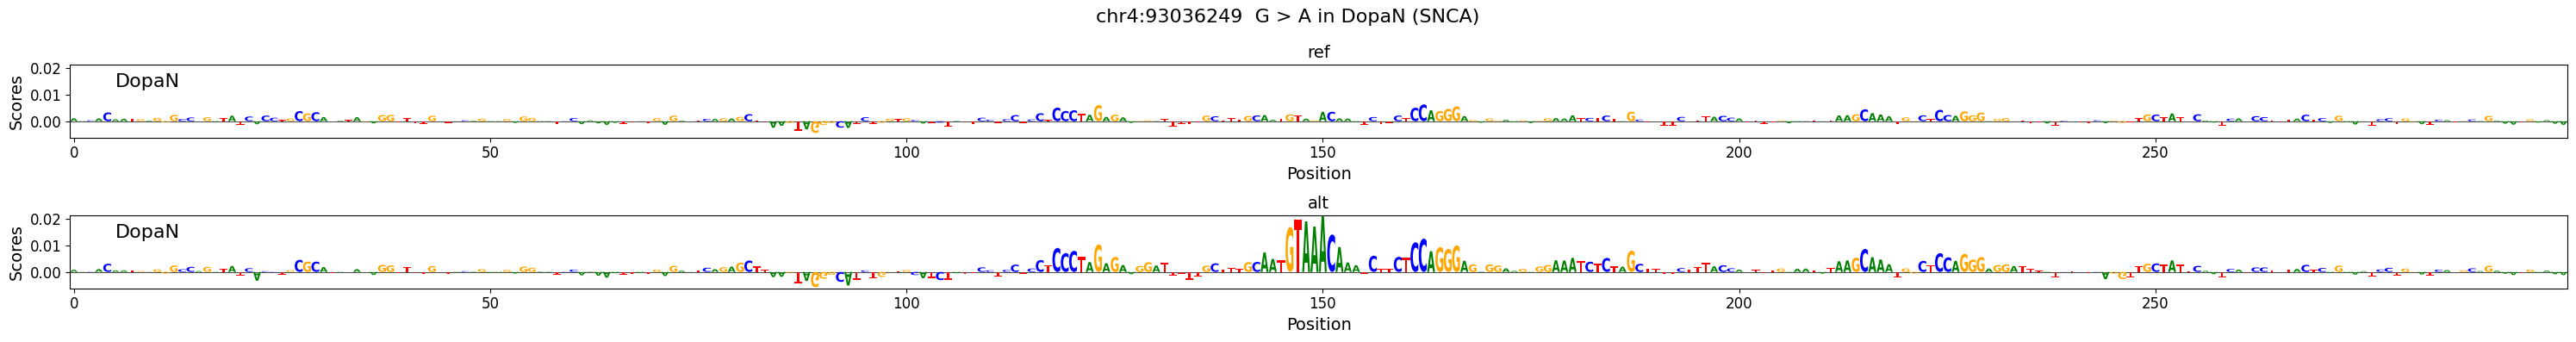

{'ct': 'Micro-PVM', 'ref': 'C', 'alt': 'T', 'gene': 'LRRK2'}
TCA
TTA
2026-03-13T10:17:00.984710+0100 INFO Calculating contribution scores for 1 class(es) and 2 region(s).


Model: 100%|██████████| 1/1 [00:03<00:00,  3.31s/it]


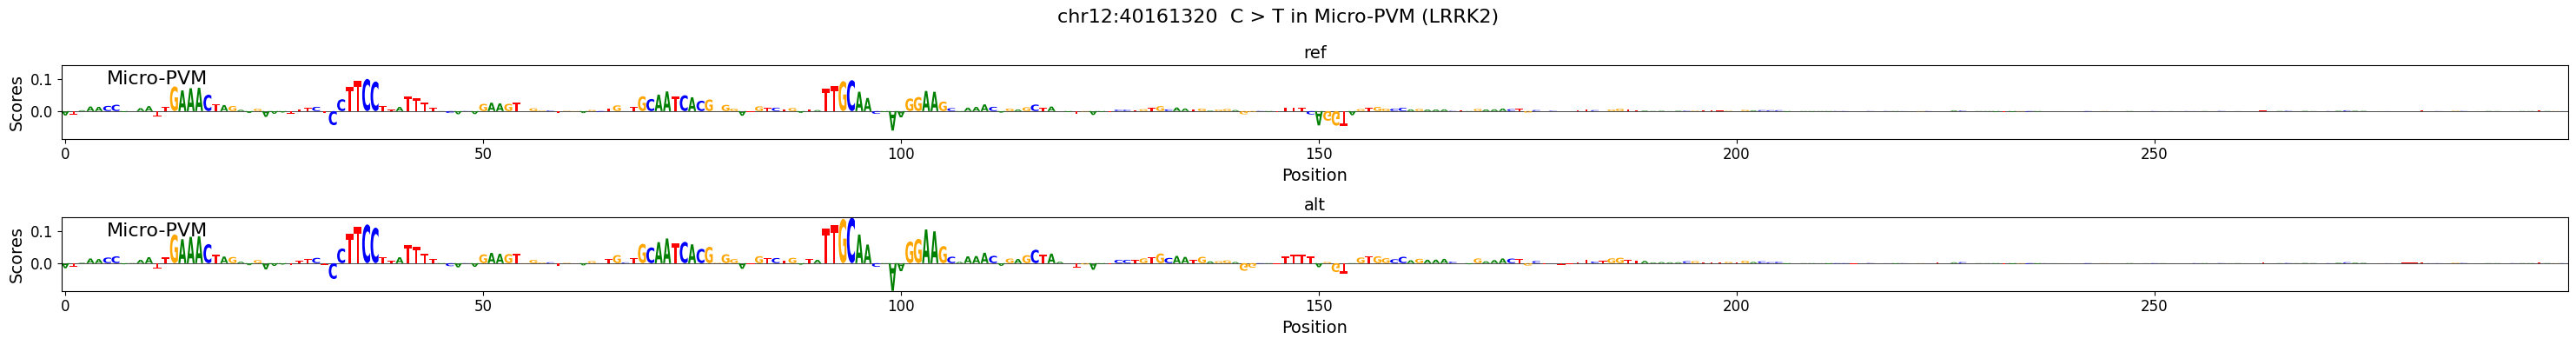

{'ct': 'Astro', 'ref': 'G', 'alt': 'A', 'gene': 'CD38'}
CGT
CAT
2026-03-13T10:17:07.479553+0100 INFO Calculating contribution scores for 1 class(es) and 2 region(s).


Model: 100%|██████████| 1/1 [00:03<00:00,  3.30s/it]


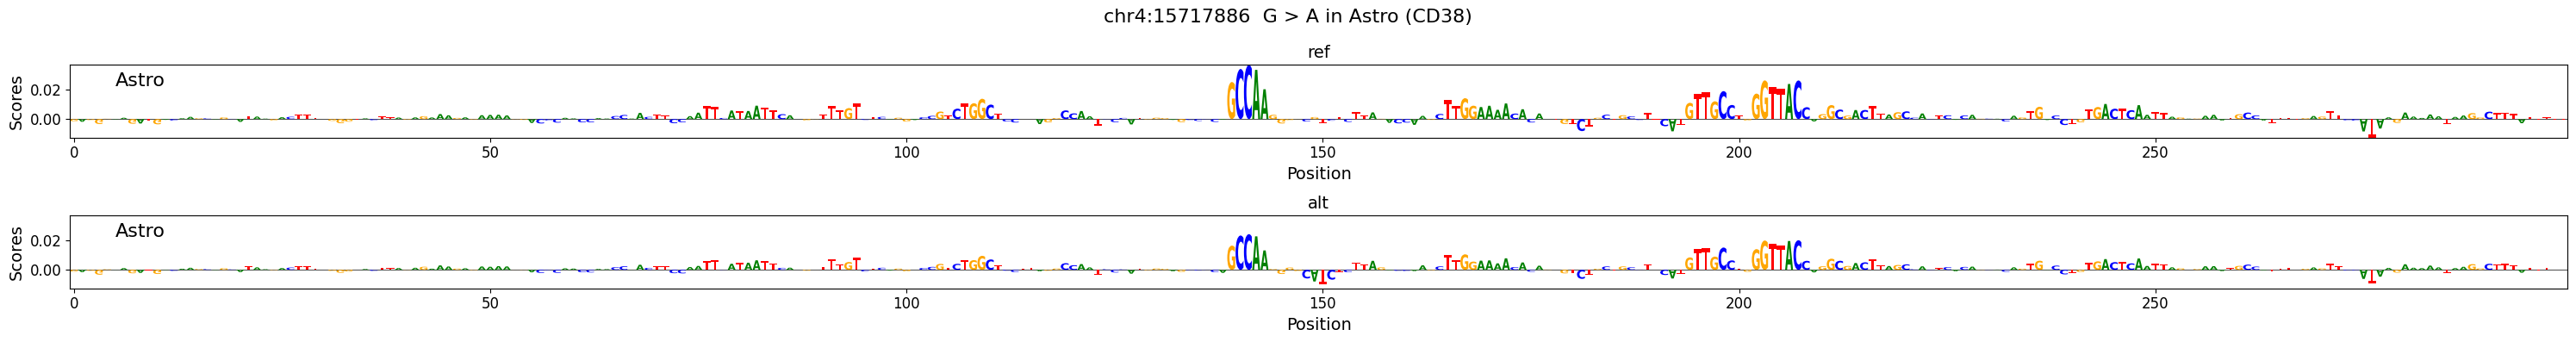

{'ct': 'Oligo', 'ref': 'G', 'alt': 'A', 'gene': 'MOBP'}
CGC
CAC
2026-03-13T10:17:14.553486+0100 INFO Calculating contribution scores for 1 class(es) and 2 region(s).


Model: 100%|██████████| 1/1 [00:03<00:00,  3.31s/it]


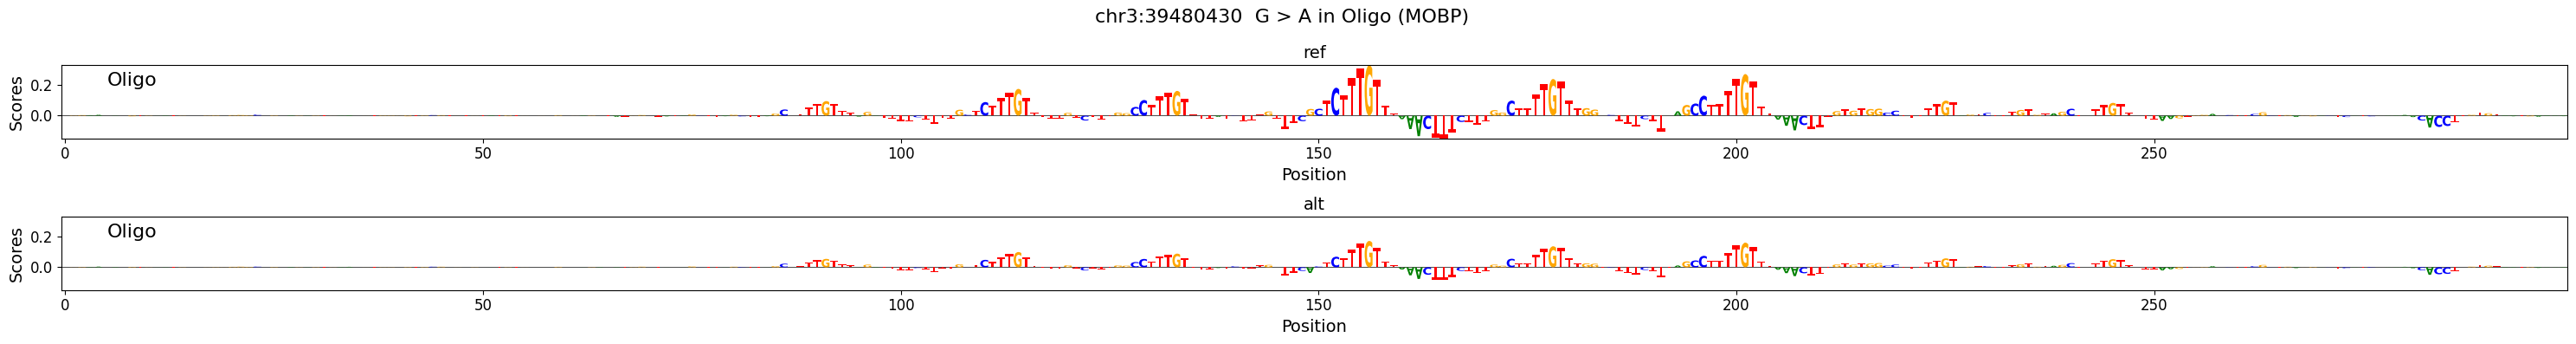

{'ct': 'Micro-PVM', 'ref': 'T', 'alt': 'A', 'gene': 'KCNMA1'}
TTC
TAC
2026-03-13T10:17:21.010060+0100 INFO Calculating contribution scores for 1 class(es) and 2 region(s).


Model: 100%|██████████| 1/1 [00:03<00:00,  3.31s/it]


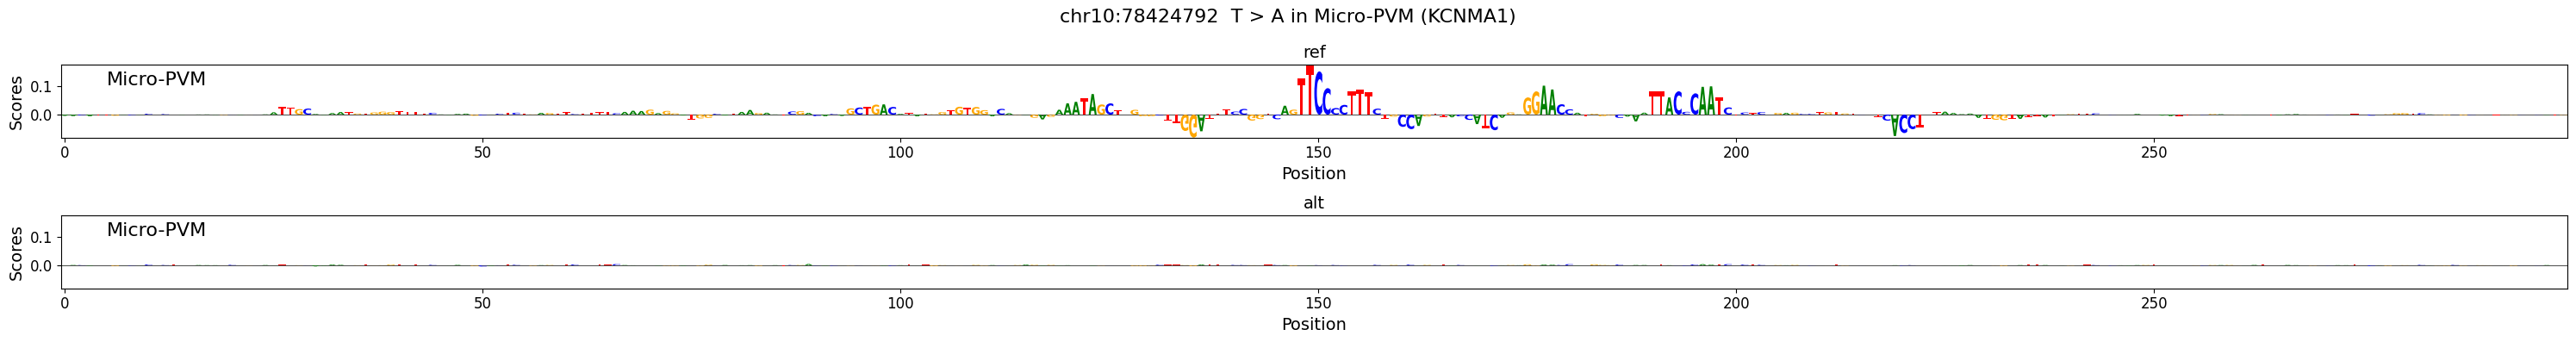

In [14]:
for var, vardic in variants.items():
    print(vardic)
    ref = get_seq_str(f'{var.split(":")[0]}:{int(var.split(":")[1])-1057}-{int(var.split(":")[1])+1057}',fasta)
    alt = ref[:1056] + vardic['alt'] + ref[1057:]
    print(ref[1055:1058])
    print(alt[1055:1058])
    scores, oh = crested.tl.contribution_scores(
            [ref,alt],
            target_idx=[list(sn_adata.obs.index).index(vardic['ct'])],
            model=sn_model,
        )
    crested.pl.patterns.contribution_scores(
        scores,
        oh,
        sequence_labels=['ref','alt'],
        class_labels=[vardic['ct']],
        zoom_n_bases=300,
        title=f"{var}  {vardic['ref']} > {vardic['alt']} in {vardic['ct']} ({vardic['gene']})",
        ylim=(np.min(scores*oh), np.max(scores*oh)),
        save_path=f"DX_{var}_{vardic['ref']}_{vardic['alt']}.pdf"
    )

In [91]:
scores, oh = crested.tl.contribution_scores(
            [ref,alt],
            target_idx=[list(sn_adata.obs.index).index('DopaN')],
            model=sn_model,
            # output_dir=f'pan_mam_contrib_{mam}/{ct}/batch_{i}'
        )

2026-03-12T22:01:58.553035+0100 INFO Calculating contribution scores for 1 class(es) and 2 region(s).


Model: 100%|██████████| 1/1 [01:56<00:00, 116.36s/it]


In [93]:
scores.shape #[0].shape

(2, 1, 2114, 4)

In [94]:
oh.shape

(2, 2114, 4)

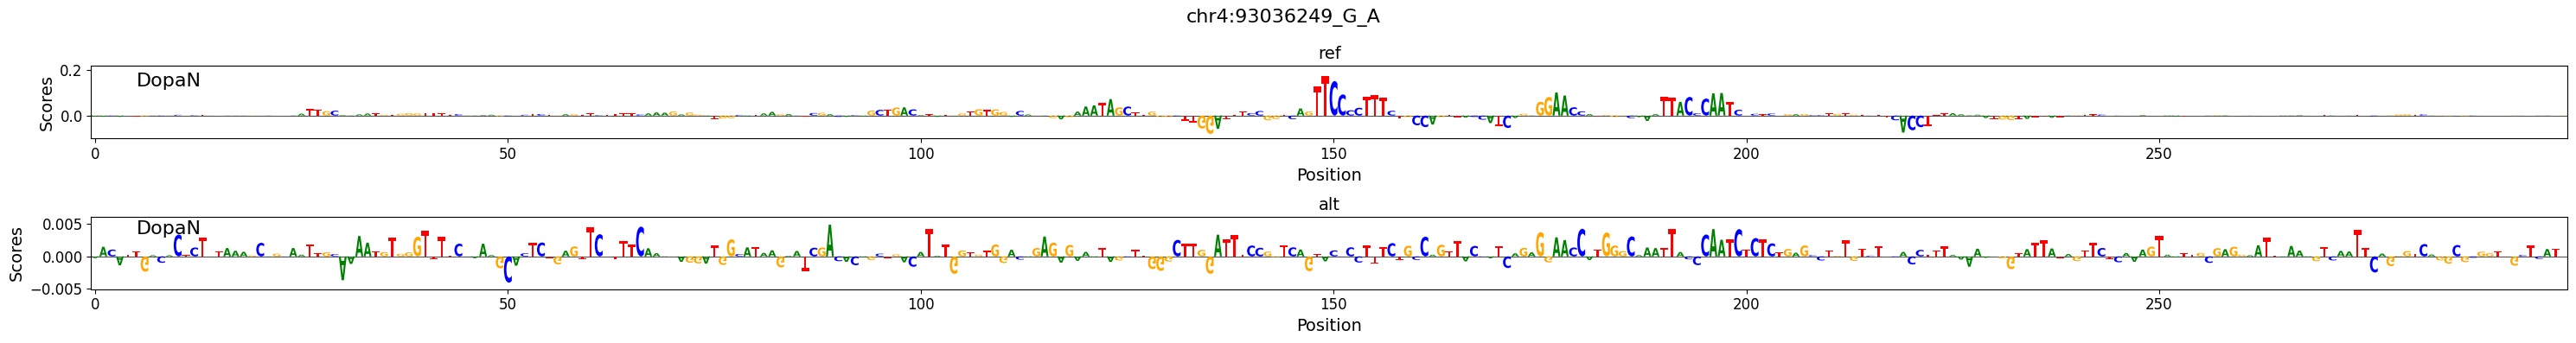

In [20]:
crested.pl.patterns.contribution_scores(
    scores,
    oh,
    sequence_labels=['ref','alt'],
    class_labels=['DopaN'],
    zoom_n_bases=300,
    title="chr4:93036249_G_A",
    save_path='test.pdf'
)

# plt.gcf().savefig("contribution_scores.pdf", bbox_inches="tight")

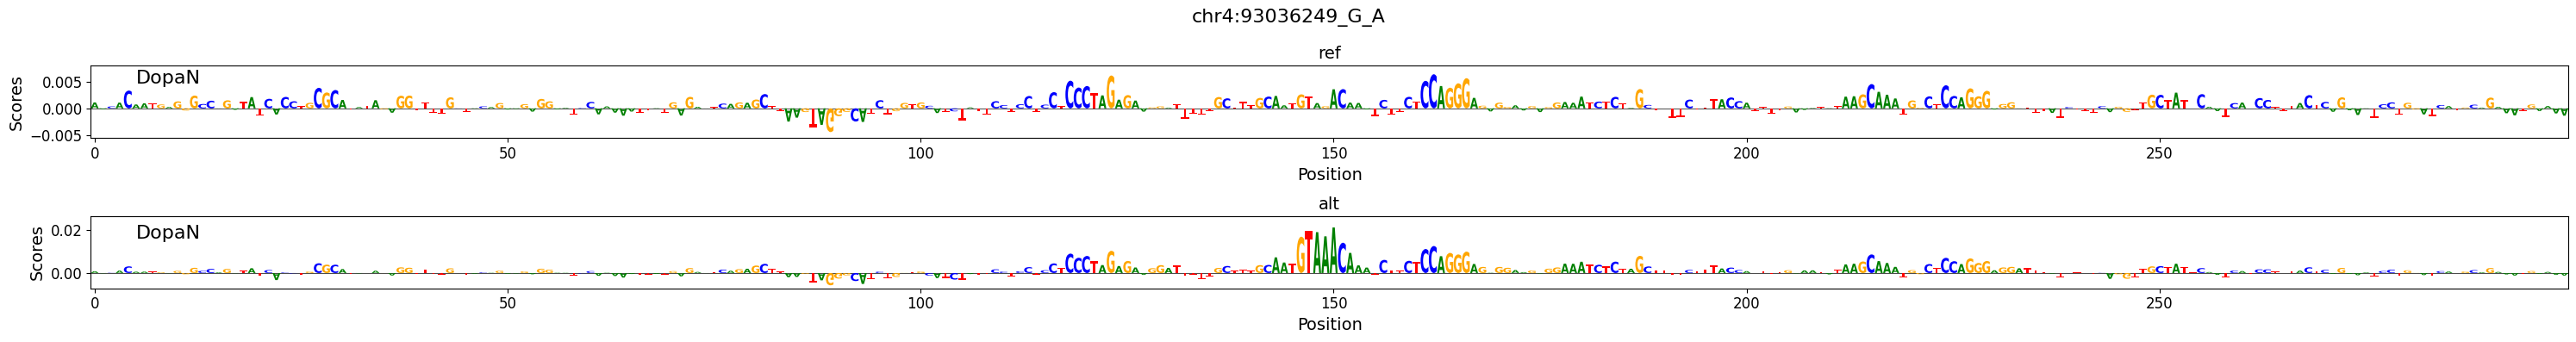

In [102]:
fig = crested.pl.patterns.contribution_scores(
    scores,
    oh,
    sequence_labels=['ref','alt'],
    class_labels=['DopaN'],
    zoom_n_bases=300,
    title="chr4:93036249_G_A",
)

In [103]:
fig.savefig("contribution_scores.pdf", bbox_inches="tight")

AttributeError: 'NoneType' object has no attribute 'savefig'

In [100]:
fig

In [99]:
crested.pl.render_plot(fig)

AttributeError: 'NoneType' object has no attribute 'set_size_inches'